# Анализ ликвидности автомобильных объявлений и рекомендации по VAS

Работа по данным liquidity_base.csv и liquidity_cnt.csv

Цель анализа:
- понять, какие факторы сильнее всего связаны с ликвидностью объявлений
- выделить сегменты высокой и низкой ликвидности
- разобрать, как контакты распределяются по дням жизни объявления
- определить практические правила, когда имеет смысл рекомендовать платное продвижение VAS


## Краткая постановка задачи

Мы анализируем ликвидность автомобильных объявлений на Авито: какие факторы определяют скорость и объём контактов, когда именно продавцу стоит подключать VAS, и можно ли предлагать разные стратегии для разных типов объявлений.

**Ликвидность** в контексте этой работы - не одна метрика, а набор показателей:
- **total_contacts**: сколько контактов объявление набрало за всю жизнь
- **avg_contacts_per_day**: интенсивность спроса
- **early contacts**: насколько быстро рынок откликнулся в первые дни
- **day_to_50%/80%**: как быстро объявление вычерпывает основной спрос

Мы разделяем эти вещи, потому что объявление, набравшее 20 контактов за месяц — совсем не то же самое, что объявление с теми же 20 контактами за первые три дня

In [88]:
from pathlib import Path

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

!pip install scipy

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, kruskal, mannwhitneyu, chi2_contingency
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.cluster import MiniBatchKMeans
import statsmodels.api as sm
import statsmodels.formula.api as smf

from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12


# Дополнительные библиотеки для расширенного анализа
!pip install -q lifelines lightgbm shap plotly 2>/dev/null
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from scipy.stats import rankdata
import lightgbm as lgb
import shap
import plotly.express as px

/Users/maksimvolkov/Desktop/ITMO/avito_hack/.venv/bin/pip: line 2: /Users/maksimvolkov/Desktop/ITMO/хакатон авито/.venv/bin/python: No such file or directory
/Users/maksimvolkov/Desktop/ITMO/avito_hack/.venv/bin/pip: line 2: exec: /Users/maksimvolkov/Desktop/ITMO/хакатон авито/.venv/bin/python: cannot execute: No such file or directory


## Загрузка данных


In [89]:
def resolve_path(filename: str) -> Path:
    candidates = [
        Path(filename),
        Path.cwd() / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f"Не удалось найти файл: {filename}")

base_path = resolve_path("liquidity_base.csv")
cnt_path = resolve_path("liquidity_cnt.csv")

base = pd.read_csv(base_path, parse_dates=["start_time", "close_time"])
cnt = pd.read_csv(cnt_path)

print("base:", base.shape)
print("cnt :", cnt.shape)


base: (412801, 23)
cnt : (2359590, 4)


## Первичный осмотр данных


In [90]:
display(base.head())
display(cnt.head())

print("\nКолонки base:")
print(list(base.columns))

print("\nКолонки cnt:")
print(list(cnt.columns))


,Unnamed: 0,id,start_time,close_time,brand,model,generation,body_type,year,mileage,...,equipment,fuel_type,transmission,drive,color,region,condition,rating,reviews,removal_reason
0,0,263951,2024-07-20 16:51:47.744669,2024-08-14 20:35:34.353783,Kia,Sorento,I (2002—2006),Внедорожник,2002,290000,...,Базовая,Дизель,Автомат,Полный,Серый,Воронежская область,Не битый,5.0,4.0,Продано на Avito
1,1,223634,2024-07-17 15:35:34.290251,2024-07-19 11:38:22.750530,Kia,Sorento,II рестайлинг (2012—2021),Внедорожник,2014,131000,...,Classic,Бензин,Автомат,Полный,Серый,Москва,Не битый,NaN,NaN,NaN
2,2,282105,2024-07-22 10:19:17.534577,2024-07-31 18:29:03.218218,Toyota,Land Cruiser Prado,150 (2009—2013),Внедорожник,2012,250000,...,Elegance,Дизель,Автомат,Полный,Серый,Удмуртия,Не битый,5.0,11.0,Другая причина
3,3,108565,2024-07-08 22:11:23.788182,2024-09-07 10:38:38.021999,ВАЗ (LADA),Granta,I (2011—2018),Лифтбек,2016,150000,...,Comfort,Бензин,Механика,Передний,Синий,Башкортостан,Не битый,5.0,3.0,NaN
4,4,228568,2024-07-17 20:49:44.749832,2024-09-04 08:19:21.514770,Volkswagen,Polo,V (2009—2015),Седан,2013,213433,...,NaN,Бензин,Механика,Передний,Синий,Ставропольский край,Не битый,2.0,1.0,Продано на Avito


,Unnamed: 0,id,day,cnt_contacts
0,0,75908,1,1
1,1,100916,18,2
2,2,159243,14,1
3,3,207651,43,1
4,4,14109,14,3



Колонки base:
['Unnamed: 0', 'id', 'start_time', 'close_time', 'brand', 'model', 'generation', 'body_type', 'year', 'mileage', 'price', 'imv', 'modification', 'equipment', 'fuel_type', 'transmission', 'drive', 'color', 'region', 'condition', 'rating', 'reviews', 'removal_reason']

Колонки cnt:
['Unnamed: 0', 'id', 'day', 'cnt_contacts']


## Аудит данных


In [91]:
audit_summary = {
    "base_rows": len(base),
    "base_unique_id": base["id"].nunique(),
    "base_duplicate_ids": int(base["id"].duplicated().sum()),
    "cnt_rows": len(cnt),
    "cnt_unique_id": cnt["id"].nunique(),
    "cnt_duplicate_rows": int(cnt.duplicated().sum()),
    "cnt_duplicate_id_day": int(cnt.duplicated(["id", "day"]).sum()),
}
pd.Series(audit_summary)


base_rows                412801
base_unique_id           412801
base_duplicate_ids            0
cnt_rows                2359590
cnt_unique_id            330852
cnt_duplicate_rows            0
cnt_duplicate_id_day          0
dtype: int64

In [92]:
missing_base = (
    base.isna().mean()
    .sort_values(ascending=False)
    .rename("missing_share")
    .to_frame()
)
display(missing_base.head(12))

numeric_cols = ["year", "mileage", "price", "imv", "rating", "reviews"]
display(base[numeric_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

display(cnt[["day", "cnt_contacts"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]).T)


,missing_share
reviews,0.255341
rating,0.255341
equipment,0.231344
imv,0.167437
removal_reason,0.149285
modification,0.001730
generation,0.000390
model,0.000000
transmission,0.000000
start_time,0.000000


,count,mean,std,min,1%,5%,50%,95%,99%,max
year,412801.0,2.010818e+03,7.870907e+00,1928.0,1987.0,1997.0,2011.000000,2022.0,2024.0,2.026000e+03
mileage,412801.0,1.630144e+05,1.038367e+05,1.0,25.0,16000.0,155000.000000,340000.0,460203.0,1.000000e+06
price,412801.0,1.313355e+06,9.910799e+06,1.0,60000.0,110000.0,750000.000000,3800000.0,9350000.0,5.000000e+09
imv,343683.0,9.737665e+05,1.268548e+06,3400.0,76100.0,115500.0,644200.000000,2823400.0,5705200.0,7.507250e+07
rating,307396.0,4.628535e+00,6.708977e-01,1.0,1.0,3.5,4.892308,5.0,5.0,5.000000e+00
reviews,307396.0,2.107560e+02,7.873524e+02,1.0,1.0,1.0,12.000000,1037.0,4116.0,9.901000e+03


,count,mean,std,min,50%,90%,95%,99%,99.9%,max
day,2359590.0,17.510289,16.143814,1.0,13.0,42.0,52.0,67.0,80.0,90.0
cnt_contacts,2359590.0,2.767577,5.444171,1.0,2.0,6.0,8.0,17.0,45.0,2894.0


Данные в целом чистые, но несколько вещей нас зацепили:
- пропуск **IMV** (16.7%) - неслучайный: у битых авто IMV отсутствует почти всегда (97.9%)
- пропуски **rating** и **reviews** (25.5%) — скорее всего связаны с типом продавца
- есть экстремальные значения (год до 1928, пробег > 1 млн), но мы не чистили их массово, а ограничивали влияние через медианы и биннинг

Отдельная деталь: в `liquidity_cnt` поле контактов называется `cnt_contacts`, а не `contacts`

In [93]:
base = base.drop(columns=[c for c in base.columns if c.startswith("Unnamed")], errors="ignore")
cnt = cnt.drop(columns=[c for c in cnt.columns if c.startswith("Unnamed")], errors="ignore")

# IMV missing ~ condition
imv_by_condition = pd.crosstab(
    base["condition"],
    base["imv"].isna(),
    normalize="index"
).rename(columns={False: "imv_present", True: "imv_missing"})

display(imv_by_condition)


imv,imv_present,imv_missing
condition,,
Битый,0.020930,0.979070
Не битый,0.858745,0.141255


Пропуск imv выглядит неслучайным: почти у всех битых автомобилей IMV отсутствует.  
Это значит, что выводы про price_to_imv и price_gap_pct корректнее читать в основном для небитых объявлений


## Очистка и подготовка

Мы не делали агрессивную фильтрацию рынка

Логика такая:

- удалить только явно технические поля
- не выкидывать объявления без контактов
- для метрик вида price_to_imv и price_gap_pct оставить NaN, если imv нет
- для графиков и некоторых проверок использовать клиппинг экстремумов, а не массовое удаление строк


In [94]:
# Агрегация контактов
agg_contacts = (
    cnt.groupby("id")
    .agg(
        total_contacts=("cnt_contacts", "sum"),
        active_contact_days=("day", "nunique"),
        max_day_with_contacts=("day", "max"),
        peak_day_contacts=("cnt_contacts", "max"),
    )
    .reset_index()
)

df = base.merge(agg_contacts, on="id", how="left")

for col in ["total_contacts", "active_contact_days", "max_day_with_contacts", "peak_day_contacts"]:
    df[col] = df[col].fillna(0)

df["lifetime_days"] = np.ceil(
    (df["close_time"] - df["start_time"]).dt.total_seconds() / 86400
).astype(int).clip(lower=1)

df["avg_contacts_per_day"] = df["total_contacts"] / df["lifetime_days"]
df["analysis_year"] = df["start_time"].dt.year
df["age_of_car"] = (df["analysis_year"] - df["year"]).clip(lower=0)

df["price_to_imv"] = df["price"] / df["imv"]
df["price_gap_pct"] = (df["price"] - df["imv"]) / df["imv"]

capital_regions = ["Москва", "Московская область", "Санкт-Петербург", "Ленинградская область"]
premium_brands = {
    "BMW", "Mercedes-Benz", "Audi", "Lexus", "Porsche", "Land Rover", "Jaguar",
    "Infiniti", "Volvo", "Cadillac", "Genesis", "Acura", "MINI", "Tesla",
    "Maserati", "Bentley", "Rolls-Royce", "Ferrari", "Lamborghini",
    "Aston Martin", "Maybach", "EXEED", "Hongqi"
}
domestic_brands = {"ВАЗ (LADA)", "LADA", "УАЗ", "ГАЗ", "Москвич", "ЗАЗ", "ТагАЗ", "DERWAYS", "SMZ", "SeAZ", "Aurus"}

df["capital_flag"] = df["region"].isin(capital_regions)
df["premium_flag"] = df["brand"].isin(premium_brands)
df["domestic_flag"] = df["brand"].isin(domestic_brands)

df["age_bin"] = pd.cut(
    df["age_of_car"],
    bins=[-0.1, 2, 5, 10, 15, np.inf],
    labels=["0-2", "3-5", "6-10", "11-15", "16+"]
)

df["mileage_bin"] = pd.cut(
    df["mileage"],
    bins=[-1, 50_000, 100_000, 150_000, 200_000, 300_000, np.inf],
    labels=["<=50k", "50-100k", "100-150k", "150-200k", "200-300k", "300k+"]
)

df["price_bin"] = pd.cut(
    df["price"],
    bins=[-1, 300_000, 700_000, 1_500_000, 3_000_000, np.inf],
    labels=["<300k", "300-700k", "700k-1.5m", "1.5-3m", "3m+"]
)

df["price_gap_bin"] = pd.cut(
    df["price_gap_pct"],
    bins=[-np.inf, -0.10, 0.10, 0.30, np.inf],
    labels=["<=-10%", "-10%..+10%", "+10%..+30%", ">+30%"]
)

df["seller_rating_bin"] = pd.cut(
    df["rating"].fillna(-1),
    bins=[-2, 0, 4.5, 4.9, 5.01],
    labels=["Нет рейтинга", "<4.5", "4.5-4.9", "4.9-5.0"],
    right=False
)

df["reviews_bin"] = pd.cut(
    df["reviews"].fillna(-1),
    bins=[-2, 0, 1, 5, 20, 100, 1000, np.inf],
    labels=["No reviews", "1", "2-5", "6-20", "21-100", "101-1000", "1000+"]
)

df[[
    "id", "lifetime_days", "total_contacts", "avg_contacts_per_day",
    "age_of_car", "price_to_imv", "price_gap_pct"
]].head()


,id,lifetime_days,total_contacts,avg_contacts_per_day,age_of_car,price_to_imv,price_gap_pct
0,263951,26,69.0,2.653846,22,1.147750,0.147750
1,223634,2,1.0,0.500000,10,0.889587,-0.110413
2,282105,10,4.0,0.400000,12,0.953355,-0.046645
3,108565,61,5.0,0.081967,8,1.071067,0.071067
4,228568,49,67.0,1.367347,11,1.151648,0.151648


## Конструирование признаков

Кроме агрегированных метрик, для анализа динамики удобно добавить контакты и накопленные контакты к фиксированным дням жизни объявления


In [95]:
selected_days = [1, 2, 3, 5, 7, 10, 14, 21, 30]

day_pivot = (
    cnt[cnt["day"].isin(selected_days)]
    .pivot(index="id", columns="day", values="cnt_contacts")
    .fillna(0)
)
day_pivot.columns = [f"contacts_day_{day}" for day in day_pivot.columns]

df = df.merge(day_pivot, left_on="id", right_index=True, how="left")
for col in day_pivot.columns:
    df[col] = df[col].fillna(0)

for day in selected_days:
    cum = (
        cnt[cnt["day"] <= day]
        .groupby("id")["cnt_contacts"]
        .sum()
        .rename(f"cum_contacts_day_{day}")
    )
    df = df.merge(cum, left_on="id", right_index=True, how="left")
    df[f"cum_contacts_day_{day}"] = df[f"cum_contacts_day_{day}"].fillna(0)

for day in [3, 5, 7, 10, 14, 21, 30]:
    df[f"share_contacts_first_{day}d"] = np.where(
        df["total_contacts"] > 0,
        df[f"cum_contacts_day_{day}"] / df["total_contacts"],
        np.nan
    )

cnt_sorted = cnt.sort_values(["id", "day"]).copy()
cnt_sorted["cum_contacts"] = cnt_sorted.groupby("id")["cnt_contacts"].cumsum()
cnt_sorted = cnt_sorted.merge(
    df[["id", "total_contacts"]],
    on="id",
    how="left"
)

for pct in [0.5, 0.8]:
    tmp = (
        cnt_sorted[cnt_sorted["cum_contacts"] >= pct * cnt_sorted["total_contacts"]]
        .groupby("id")["day"]
        .min()
        .rename(f"day_to_{int(pct * 100)}pct_contacts")
    )
    df = df.merge(tmp, on="id", how="left")

display(df[[
    "total_contacts", "avg_contacts_per_day",
    "contacts_day_1", "cum_contacts_day_7",
    "share_contacts_first_7d", "day_to_50pct_contacts"
]].head())


,total_contacts,avg_contacts_per_day,contacts_day_1,cum_contacts_day_7,share_contacts_first_7d,day_to_50pct_contacts
0,69.0,2.653846,0.0,14.0,0.202899,14.0
1,1.0,0.500000,1.0,1.0,1.000000,1.0
2,4.0,0.400000,2.0,4.0,1.000000,1.0
3,5.0,0.081967,0.0,2.0,0.400000,13.0
4,67.0,1.367347,13.0,35.0,0.522388,7.0


## Определение метрик ликвидности


In [96]:
overall_metrics = pd.Series({
    "ads": len(df),
    "ads_with_any_contacts": int((df["total_contacts"] > 0).sum()),
    "share_with_any_contacts": (df["total_contacts"] > 0).mean(),
    "median_total_contacts": df["total_contacts"].median(),
    "mean_total_contacts": df["total_contacts"].mean(),
    "median_contacts_per_day": df["avg_contacts_per_day"].median(),
    "mean_contacts_per_day": df["avg_contacts_per_day"].mean(),
    "median_lifetime_days": df["lifetime_days"].median(),
})

display(overall_metrics.to_frame("value"))


,value
ads,412801.000000
ads_with_any_contacts,330852.000000
share_with_any_contacts,0.801481
median_total_contacts,6.000000
mean_total_contacts,15.819603
median_contacts_per_day,0.333333
mean_contacts_per_day,1.117921
median_lifetime_days,17.000000


Среднее в 2.5 раза выше медианы, поэтому дальше мы ориентируемся на медианы и квантили, а не на среднее

## Базовые распределения


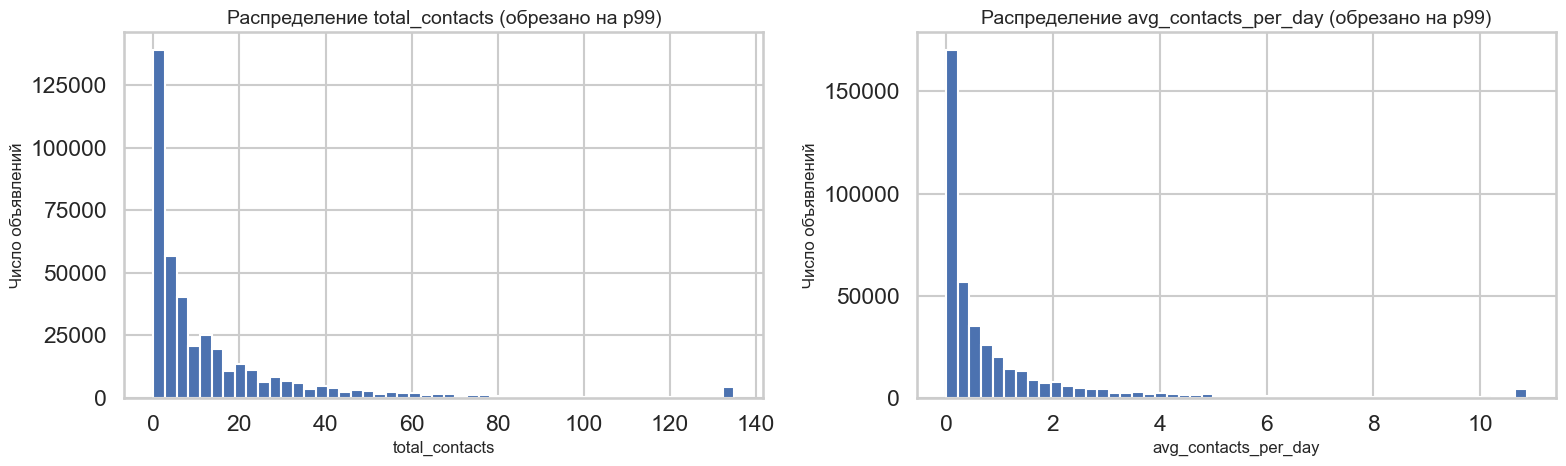

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df["total_contacts"].clip(upper=df["total_contacts"].quantile(0.99)), bins=50)
axes[0].set_title("Распределение total_contacts (обрезано на p99)")
axes[0].set_xlabel("total_contacts")
axes[0].set_ylabel("Число объявлений")

axes[1].hist(df["avg_contacts_per_day"].clip(upper=df["avg_contacts_per_day"].quantile(0.99)), bins=50)
axes[1].set_title("Распределение avg_contacts_per_day (обрезано на p99)")
axes[1].set_xlabel("avg_contacts_per_day")
axes[1].set_ylabel("Число объявлений")

plt.tight_layout()
plt.show()


Обе метрики имеют тяжёлый хвост

Для визуализации используем лог-шкалы и биннинг, чтобы не искажать картину выбросами

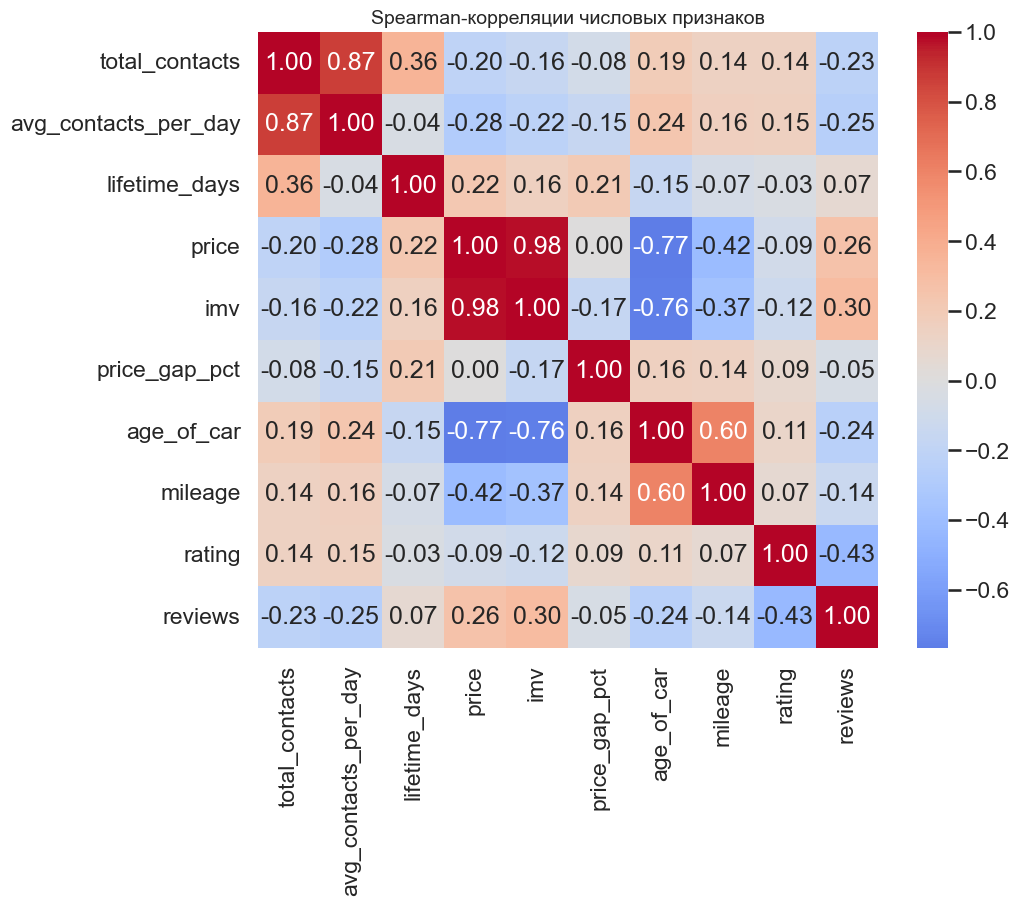

In [98]:
numeric_corr_df = df[[
    "total_contacts", "avg_contacts_per_day", "lifetime_days", "price", "imv",
    "price_gap_pct", "age_of_car", "mileage", "rating", "reviews"
]].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_corr_df, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Spearman-корреляции числовых признаков")
plt.show()


Корреляционная матрица даёт ориентир по направлению связей, но по ней нельзя делать причинные выводы. Мы используем её как точку входа для дальнейшего анализа

## Исследование факторов ликвидности: одномерный срез


In [99]:
def group_summary(data, group_col, min_n=1000):
    out = (
        data.groupby(group_col)
        .agg(
            n=("id", "size"),
            median_total_contacts=("total_contacts", "median"),
            mean_total_contacts=("total_contacts", "mean"),
            median_contacts_per_day=("avg_contacts_per_day", "median"),
            mean_contacts_per_day=("avg_contacts_per_day", "mean"),
            median_lifetime=("lifetime_days", "median"),
            share_with_contacts=("total_contacts", lambda s: (s > 0).mean()),
        )
        .sort_values("median_contacts_per_day", ascending=False)
    )
    return out[out["n"] >= min_n]

display(group_summary(df[df["imv"].notna()], "price_gap_bin"))
display(group_summary(df, "price_bin"))
display(group_summary(df, "age_bin"))
display(group_summary(df, "mileage_bin"))
display(group_summary(df, "condition"))
display(group_summary(df, "seller_rating_bin"))


,n,median_total_contacts,mean_total_contacts,median_contacts_per_day,mean_contacts_per_day,median_lifetime,share_with_contacts
price_gap_bin,,,,,,,
<=-10%,36114,13.0,28.961455,1.200000,2.785821,7.0,0.778092
-10%..+10%,123257,6.0,15.603008,0.400000,1.100269,14.0,0.807151
>+30%,66080,6.0,13.382869,0.294118,0.750530,22.0,0.838923
+10%..+30%,118232,5.0,12.707355,0.272727,0.755347,20.0,0.811565


,n,median_total_contacts,mean_total_contacts,median_contacts_per_day,mean_contacts_per_day,median_lifetime,share_with_contacts
price_bin,,,,,,,
<300k,93208,11.0,23.173762,0.833333,1.946851,10.0,0.827086
300-700k,104382,8.0,17.625999,0.471346,1.241123,16.0,0.834636
700k-1.5m,116398,5.0,12.647666,0.250000,0.818711,19.0,0.787599
1.5-3m,67023,4.0,10.898483,0.171429,0.617400,24.0,0.761201
3m+,31790,4.0,10.315162,0.142857,0.433777,31.0,0.753287


,n,median_total_contacts,mean_total_contacts,median_contacts_per_day,mean_contacts_per_day,median_lifetime,share_with_contacts
age_bin,,,,,,,
16+,155011,9.0,19.766223,0.593750,1.513262,14.0,0.835586
11-15,105509,6.0,15.704338,0.363636,1.080697,17.0,0.814803
6-10,74611,5.0,13.282264,0.250000,0.886672,20.0,0.791344
3-5,54722,3.0,10.844377,0.142857,0.652766,25.0,0.722068
0-2,22948,3.0,9.804253,0.125000,0.479664,30.0,0.732177


,n,median_total_contacts,mean_total_contacts,median_contacts_per_day,mean_contacts_per_day,median_lifetime,share_with_contacts
mileage_bin,,,,,,,
300k+,32680,9.0,18.832130,0.500000,1.351135,16.0,0.848592
200-300k,93721,8.0,17.935511,0.450000,1.270903,16.0,0.832759
150-200k,86436,7.0,17.437607,0.421053,1.252068,16.0,0.821197
100-150k,75943,6.0,14.968042,0.333333,1.085361,16.0,0.798559
50-100k,66787,5.0,14.192358,0.280000,1.018304,18.0,0.781095
<=50k,57234,3.0,11.219904,0.151515,0.691106,26.0,0.721250


,n,median_total_contacts,mean_total_contacts,median_contacts_per_day,mean_contacts_per_day,median_lifetime,share_with_contacts
condition,,,,,,,
Битый,12900,9.0,20.125891,0.571429,1.792501,11.0,0.806744
Не битый,399901,6.0,15.680691,0.333333,1.096161,18.0,0.801311


,n,median_total_contacts,mean_total_contacts,median_contacts_per_day,mean_contacts_per_day,median_lifetime,share_with_contacts
seller_rating_bin,,,,,,,
4.9-5.0,152723,8.0,17.143364,0.475410,1.156202,17.0,0.842047
Нет рейтинга,105405,7.0,16.982268,0.419355,1.337179,15.0,0.816992
<4.5,68549,4.0,15.668485,0.217391,1.120165,18.0,0.742666
4.5-4.9,86124,4.0,12.169511,0.181818,0.779909,20.0,0.757373


Из однофакторного среза сразу видны две закономерности:
- **price gap** (отклонение от IMV) — самый заметный фактор: объявления ниже рынка получают в 3–4 раза больше контактов в день
- **абсолютная цена** — чем дороже автомобиль, тем уже спрос и тем длиннее время жизни

Мы ожидали, что premium-бренды будут менее ликвидными из-за узкой аудитории, но данные показали обратное: `premium_flag` положительно коррелирует с `contacts/day`

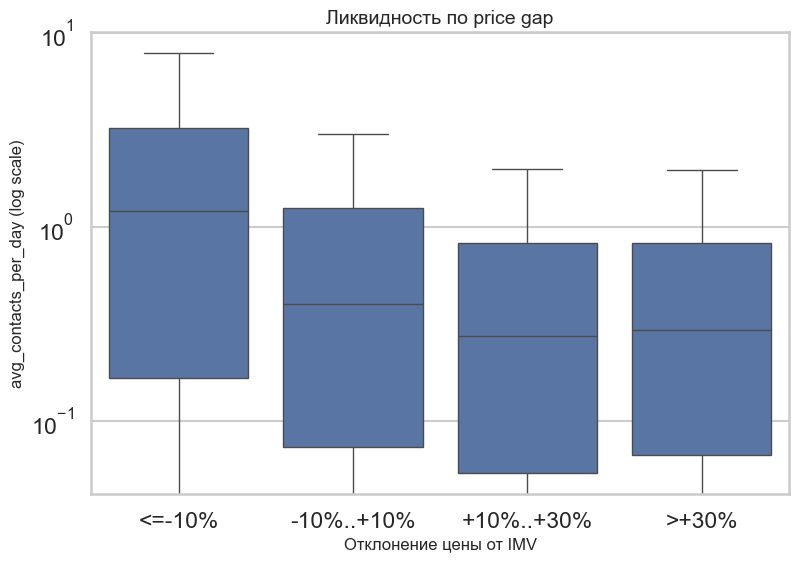

In [100]:
plot_df = df[df["imv"].notna()].copy()
plot_df["price_gap_clip"] = plot_df["price_gap_pct"].clip(-0.5, 1.0)

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=plot_df,
    x="price_gap_bin",
    y="avg_contacts_per_day",
    showfliers=False
)
plt.yscale("log")
plt.xlabel("Отклонение цены от IMV")
plt.ylabel("avg_contacts_per_day (log scale)")
plt.title("Ликвидность по price gap")
plt.show()


Даже после перехода в лог-шкалу видно, что overpriced-объявления системно проигрывают по дневной интенсивности контактов, поэтому это не артефакт, так как эффект устойчив

In [101]:
corr_rows = []
for feature in ["price", "imv", "price_gap_pct", "age_of_car", "mileage", "rating", "reviews", "lifetime_days"]:
    sub = df[[feature, "total_contacts", "avg_contacts_per_day"]].dropna()
    rho_total, p_total = spearmanr(sub[feature], sub["total_contacts"])
    rho_day, p_day = spearmanr(sub[feature], sub["avg_contacts_per_day"])
    corr_rows.append({
        "feature": feature,
        "n": len(sub),
        "spearman_total_contacts": rho_total,
        "p_total_contacts": p_total,
        "spearman_contacts_per_day": rho_day,
        "p_contacts_per_day": p_day,
    })

corr_table = pd.DataFrame(corr_rows).sort_values("spearman_contacts_per_day")
display(corr_table.round(4))


,feature,n,spearman_total_contacts,p_total_contacts,spearman_contacts_per_day,p_contacts_per_day
0,price,412801,-0.2016,0.0,-0.2777,0.0
6,reviews,307396,-0.2257,0.0,-0.2518,0.0
1,imv,343683,-0.1639,0.0,-0.2218,0.0
2,price_gap_pct,343683,-0.0785,0.0,-0.1543,0.0
7,lifetime_days,412801,0.3574,0.0,-0.0397,0.0
5,rating,307396,0.1422,0.0,0.1517,0.0
4,mileage,412801,0.1413,0.0,0.1581,0.0
3,age_of_car,412801,0.1912,0.0,0.2396,0.0


Ранговые корреляции подтверждают то же направление:
- price и price_gap_pct — отрицательная связь с contacts/day
- age_of_car и mileage — положительная (через связку с ценой)
- rating — положительная, но умеренная

## Многомерная проверка: Negative Binomial модель

Однофакторный анализ может быть обманчив из-за того, что факторы коррелируют между собой. Для контроля мы используем Negative Binomial GLM, который подходит для count-data с overdispersion

In [102]:
model_df = df.copy()

model_df["price_gap_bin_m"] = model_df["price_gap_bin"].astype(object).where(
    model_df["price_gap_bin"].notna(), "IMV unknown"
)

for col in ["price_gap_bin_m", "price_bin", "age_bin", "condition", "transmission", "reviews_bin"]:
    model_df[col] = model_df[col].astype(str)

sample = model_df.sample(120_000, random_state=42)

formula = '''
total_contacts ~
C(price_gap_bin_m, Treatment(reference="-10%..+10%")) +
C(price_bin, Treatment(reference="300-700k")) +
C(age_bin, Treatment(reference="6-10")) +
C(condition, Treatment(reference="Не битый")) +
C(transmission, Treatment(reference="Автомат")) +
C(reviews_bin, Treatment(reference="6-20")) +
capital_flag + premium_flag + domestic_flag
'''

nb_model = smf.glm(
    formula=formula,
    data=sample,
    family=sm.families.NegativeBinomial(alpha=1.0),
    exposure=sample["lifetime_days"]
).fit(maxiter=100, disp=0)

coef_table = pd.DataFrame({
    "coef": nb_model.params,
    "rate_ratio": np.exp(nb_model.params),
    "p_value": nb_model.pvalues,
}).sort_values("rate_ratio", ascending=False)

display(coef_table.round(3))


,coef,rate_ratio,p_value
"C(price_gap_bin_m, Treatment(reference=""-10%..+10%""))[T.<=-10%]",0.554,1.740,0.000
Intercept,0.512,1.669,0.000
capital_flag[T.True],0.373,1.453,0.000
"C(price_bin, Treatment(reference=""300-700k""))[T.<300k]",0.285,1.330,0.000
premium_flag[T.True],0.185,1.204,0.000
domestic_flag[T.True],0.155,1.168,0.000
"C(price_gap_bin_m, Treatment(reference=""-10%..+10%""))[T.IMV unknown]",0.057,1.059,0.000
"C(age_bin, Treatment(reference=""6-10""))[T.16+]",0.031,1.031,0.009
"C(age_bin, Treatment(reference=""6-10""))[T.11-15]",0.020,1.020,0.055
"C(reviews_bin, Treatment(reference=""6-20""))[T.No reviews]",0.008,1.008,0.426


In [103]:
# Более компактный вид только для ключевых коэффициентов
interesting = coef_table.loc[
    coef_table.index.str.contains("price_gap_bin_m|price_bin|age_bin|condition|capital_flag|premium_flag|domestic_flag")
].copy()

display(interesting.round(3))


,coef,rate_ratio,p_value
"C(price_gap_bin_m, Treatment(reference=""-10%..+10%""))[T.<=-10%]",0.554,1.740,0.000
capital_flag[T.True],0.373,1.453,0.000
"C(price_bin, Treatment(reference=""300-700k""))[T.<300k]",0.285,1.330,0.000
premium_flag[T.True],0.185,1.204,0.000
domestic_flag[T.True],0.155,1.168,0.000
"C(price_gap_bin_m, Treatment(reference=""-10%..+10%""))[T.IMV unknown]",0.057,1.059,0.000
"C(age_bin, Treatment(reference=""6-10""))[T.16+]",0.031,1.031,0.009
"C(age_bin, Treatment(reference=""6-10""))[T.11-15]",0.020,1.020,0.055
"C(condition, Treatment(reference=""Не битый""))[T.Битый]",-0.122,0.885,0.000
"C(age_bin, Treatment(reference=""6-10""))[T.3-5]",-0.149,0.862,0.000


Что важно после совместного учёта факторов:
- **price_gap** остаётся главным драйвером: Rate Ratio для overpriced-групп 0.47–0.62
- **capital_flag** даёт RR = 1.45 — крупные рынки помогают, но не компенсируют завышенную цену
- **condition** перестаёт выглядеть положительным фактором после контроля цены (RR ≈ 0.88 для битых)
- возраст работает, но значительная часть его эффекта проходит через ценовую доступность

Мы используем модель не как предсказательный движок, а как средство отделить устойчивые эффекты от артефактов сырой EDA

## Оценка вклада признаков: LightGBM + SHAP

Чтобы выйти за рамки линейных коэффициентов NB-модели, мы обучаем **LightGBM** и применяем **SHAP** для оценки нелинейного вклада каждого фактора. Это позволяет увидеть, как именно конкретное значение признака (не просто его наличие) смещает предсказание ликвидности

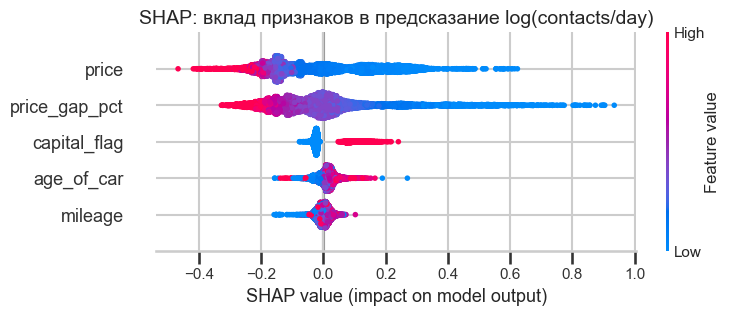

In [104]:
# LightGBM + SHAP-анализ
lgb_df = df[df["total_contacts"] > 0].copy()

feature_cols = []
for col in ["price_gap_pct", "price", "age_of_car", "mileage"]:
    if col in lgb_df.columns:
        lgb_df[col] = lgb_df[col].fillna(lgb_df[col].median())
        feature_cols.append(col)

if "capital_flag" in lgb_df.columns:
    lgb_df["capital_flag"] = lgb_df["capital_flag"].astype(int)
    feature_cols.append("capital_flag")

X_lgb = lgb_df[feature_cols]
y_lgb = np.log1p(lgb_df["avg_contacts_per_day"])

model_lgb = lgb.LGBMRegressor(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, random_state=42, verbose=-1
)
model_lgb.fit(X_lgb, y_lgb)

# SHAP на сэмпле для скорости
X_sample = X_lgb.sample(min(10_000, len(X_lgb)), random_state=42)
explainer = shap.TreeExplainer(model_lgb)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP: вклад признаков в предсказание log(contacts/day)")
plt.tight_layout()
plt.show()

**Продуктовый вывод:** `price_gap_pct` и абсолютная `price` доминируют. Высокие значения price gap (красные точки) сильно сдвигают предсказание влево (снижают ликвидность). Практически: снижение завышенной цены до рыночной даёт более резкий скачок ликвидности, чем попытки компенсировать price gap за счёт VAS. Для сегментов D и E price-nudge работает мощнее платного промо

## Дополнительная Проверка разумности сегментации деревом решений

Чтобы сегменты не выглядели произвольными, полезно посмотреть, как бы грубо делил пространство признаков очень неглубокий дерево-регрессор

Если первые сплиты тоже идут по цене и price gap, значит rule-based сегментация опирается на реальные крупные паттерны в данных


In [105]:
tree_df = df.copy()
tree_df["log_price"] = np.log1p(tree_df["price"])
tree_df["price_gap_clip"] = tree_df["price_gap_pct"].clip(-0.5, 1.0).fillna(0.15)
tree_df["age_clip"] = tree_df["age_of_car"].clip(0, 25)
tree_df["mileage_clip"] = tree_df["mileage"].clip(0, 400_000)
tree_df["imv_missing"] = tree_df["imv"].isna().astype(int)
tree_df["damaged_flag"] = (tree_df["condition"] == "Битый").astype(int)
tree_df["capital_flag_num"] = tree_df["capital_flag"].astype(int)

X_tree = tree_df[[
    "log_price", "price_gap_clip", "age_clip",
    "mileage_clip", "capital_flag_num", "imv_missing", "damaged_flag"
]]
y_tree = np.log1p(tree_df["avg_contacts_per_day"])

tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=20_000, random_state=42)
tree.fit(X_tree, y_tree)

print(export_text(tree, feature_names=list(X_tree.columns)))


|--- log_price <= 13.11
|   |--- price_gap_clip <= 0.01
|   |   |--- price_gap_clip <= -0.15
|   |   |   |--- value: [0.97]
|   |   |--- price_gap_clip >  -0.15
|   |   |   |--- value: [0.83]
|   |--- price_gap_clip >  0.01
|   |   |--- price_gap_clip <= 0.22
|   |   |   |--- value: [0.70]
|   |   |--- price_gap_clip >  0.22
|   |   |   |--- value: [0.54]
|--- log_price >  13.11
|   |--- price_gap_clip <= -0.03
|   |   |--- value: [0.70]
|   |--- price_gap_clip >  -0.03
|   |   |--- log_price <= 13.70
|   |   |   |--- value: [0.44]
|   |   |--- log_price >  13.70
|   |   |   |--- value: [0.31]



Первые сплиты дерева действительно идут по цене и отклонению от IMV.  
Это значит, что наша rule-based сегментация не произвольна, а опирается на реальные разломы в данных

## Сегментация объявлений

Мы выделяем 5 операционных сегментов на основе абсолютной цены, отклонения от IMV, региона и состояния. Пороги (300k, 700k, 1.5m) выбраны с учётом структуры рынка и подтверждены деревом решений.

> **Замечание про сегмент «Other» (Битые авто и без IMV):**
> Все битые авто и объявления без оценки IMV (~16.7% датасета) попадают в фоновый сегмент «Other». С точки зрения моделирования price_gap это оправдано, так как у них нет baseline-цены, но для бизнеса битые машины - это гигантский и ультра-ликвидный сегмент, который моментально выкупают перекупы и разборки. Исключение их из скоринга оставляет слепое пятно, поэтому в будущем для них стоит сделать отдельную логику продвижения


In [106]:
segment = pd.Series("Other", index=df.index)

segment[
    (df["condition"] != "Битый") &
    df["imv"].notna() &
    (df["price"] < 300_000) &
    (df["price_gap_pct"] <= -0.10)
] = "A. Budget bargain"

segment[
    (df["condition"] != "Битый") &
    df["imv"].notna() &
    (df["price"].between(300_000, 699_999)) &
    (df["price_gap_pct"] <= 0.10)
] = "B. Fair-priced mainstream"

segment[
    (df["condition"] != "Битый") &
    df["imv"].notna() &
    (df["price"].between(700_000, 1_499_999)) &
    (df["price_gap_pct"] <= 0.10) &
    (df["capital_flag"])
] = "C. Fair urban mid-price"

segment[
    (df["condition"] != "Битый") &
    df["imv"].notna() &
    (df["price"].between(700_000, 1_499_999)) &
    (df["price_gap_pct"] > 0.10)
] = "D. Overpriced mid-market"

segment[
    (df["condition"] != "Битый") &
    df["imv"].notna() &
    (df["price"] >= 1_500_000) &
    (df["price_gap_pct"] > 0.10)
] = "E. Expensive overpriced"

df["segment"] = segment

df["segment"].value_counts().to_frame("n")


,n
segment,
Other,252670
D. Overpriced mid-market,56580
B. Fair-priced mainstream,36669
E. Expensive overpriced,35653
A. Budget bargain,20148
C. Fair urban mid-price,11081


In [107]:
spotlight_segments = [
    "A. Budget bargain",
    "B. Fair-priced mainstream",
    "C. Fair urban mid-price",
    "D. Overpriced mid-market",
    "E. Expensive overpriced",
]

segment_profile = (
    df[df["segment"].isin(spotlight_segments)]
    .groupby("segment")
    .agg(
        n=("id", "size"),
        median_total_contacts=("total_contacts", "median"),
        mean_total_contacts=("total_contacts", "mean"),
        median_contacts_per_day=("avg_contacts_per_day", "median"),
        mean_contacts_per_day=("avg_contacts_per_day", "mean"),
        median_lifetime=("lifetime_days", "median"),
        mean_lifetime=("lifetime_days", "mean"),
        median_price=("price", "median"),
        median_price_to_imv=("price_to_imv", "median"),
        median_age=("age_of_car", "median"),
        median_mileage=("mileage", "median"),
        top_brands=("brand", lambda s: ", ".join(s.value_counts().head(3).index.tolist())),
        top_models=("model", lambda s: ", ".join(s.value_counts().head(3).index.tolist())),
        top_regions=("region", lambda s: ", ".join(s.value_counts().head(3).index.tolist())),
    )
)

display(segment_profile.round(3))


,n,median_total_contacts,mean_total_contacts,median_contacts_per_day,mean_contacts_per_day,median_lifetime,mean_lifetime,median_price,median_price_to_imv,median_age,median_mileage,top_brands,top_models,top_regions
segment,,,,,,,,,,,,,,
A. Budget bargain,20148,14.0,29.310,1.333,2.928,6.0,13.001,130000.0,0.745,19.0,193000.0,"ВАЗ (LADA), Chevrolet, ГАЗ","2114 Samara, 2107, Priora","Московская область, Санкт-Петербург, Свердловс..."
B. Fair-priced mainstream,36669,10.0,22.160,0.750,1.771,10.0,17.209,479995.0,1.000,14.0,190000.0,"ВАЗ (LADA), Chevrolet, Ford","Granta, Priora, Focus","Московская область, Санкт-Петербург, Москва"
C. Fair urban mid-price,11081,6.0,17.398,0.500,1.523,9.0,15.646,1070000.0,1.010,11.0,142564.0,"Kia, Hyundai, Volkswagen","Solaris, Rio, Polo","Москва, Московская область, Санкт-Петербург"
D. Overpriced mid-market,56580,4.0,10.053,0.195,0.503,23.0,26.794,995000.0,1.207,12.0,172000.0,"ВАЗ (LADA), Hyundai, Kia","Solaris, Rio, Focus","Москва, Московская область, Краснодарский край"
E. Expensive overpriced,35653,4.0,9.130,0.150,0.380,29.0,30.047,2190000.0,1.181,7.0,121000.0,"Toyota, Kia, BMW","Camry, Sportage, E-класс","Москва, Московская область, Санкт-Петербург"


Сегменты различаются и по уровню контактов, и по времени жизни, и по ценовому профилю. Это показывает реальную структуру рынка

## Композитный Индекс Ликвидности

Мы объединяем несколько метрик в **один показатель от 0 до 100**, который мог бы стать внутренним инструментом для Авито. Ранговое усреднение трёх компонент:
- **avg_contacts_per_day** — интенсивность
- **share_contacts_first_7d** — концентрация раннего интереса
- **day_to_50pct_contacts** (инвертированный) — скорость

/var/folders/73/j11xqg4j5y794ghwkhr2jtb00000gn/T/ipykernel_31911/3229090722.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha="right")


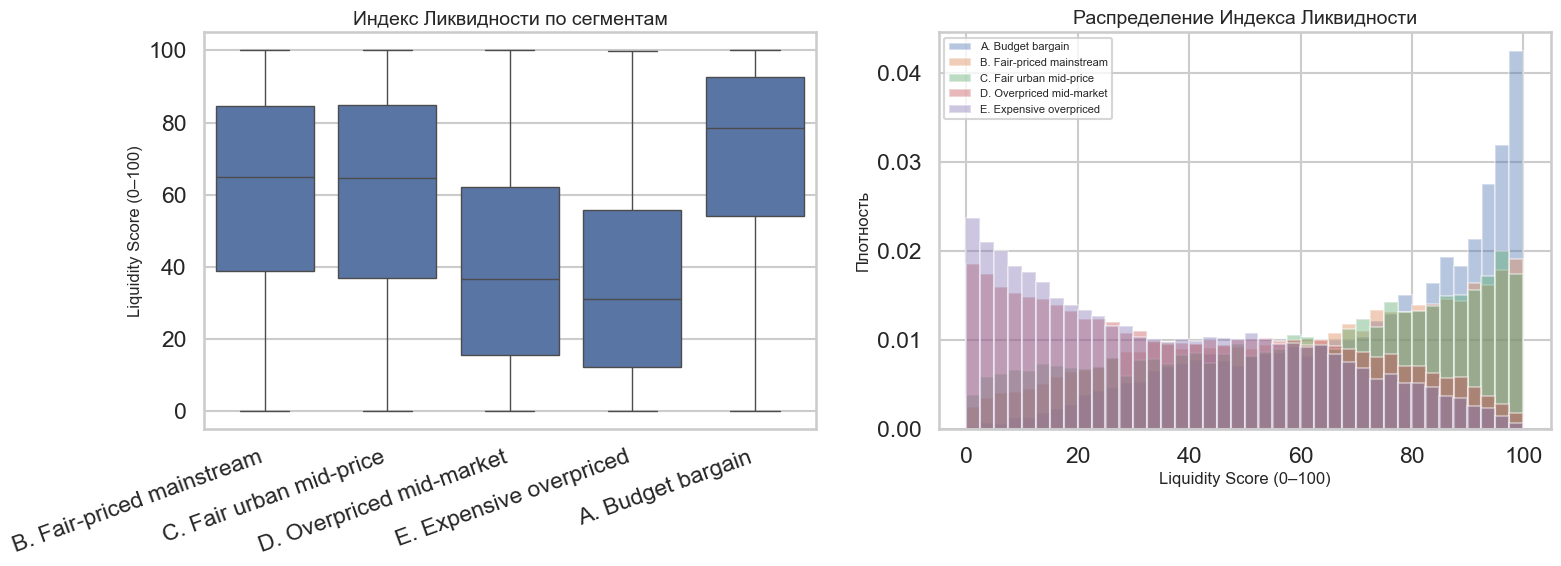

,median,mean,std
segment,,,
A. Budget bargain,78.4,71.7,24.1
B. Fair-priced mainstream,65.0,60.9,27.1
C. Fair urban mid-price,64.8,59.9,28.5
D. Overpriced mid-market,36.8,39.9,27.2
E. Expensive overpriced,31.1,35.4,25.8


In [108]:
# Индекс Ликвидности (0–100)
scored = df[df["total_contacts"] > 0].copy()

scored["speed_rank"] = rankdata(-scored["day_to_50pct_contacts"].fillna(999))
scored["intensity_rank"] = rankdata(scored["avg_contacts_per_day"])
scored["early_rank"] = rankdata(scored["share_contacts_first_7d"].fillna(0))
scored["composite_rank"] = (scored["speed_rank"] + scored["intensity_rank"] + scored["early_rank"]) / 3
scored["liquidity_score"] = (rankdata(scored["composite_rank"]) / len(scored) * 100).round(1)

df = df.merge(scored[["liquidity_score"]], left_index=True, right_index=True, how="left")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_data = df[df["segment"].isin(spotlight_segments) & df["liquidity_score"].notna()]

sns.boxplot(data=plot_data, x="segment", y="liquidity_score", ax=axes[0], showfliers=False)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha="right")
axes[0].set_xlabel("")
axes[0].set_ylabel("Liquidity Score (0–100)")
axes[0].set_title("Индекс Ликвидности по сегментам")

for seg in spotlight_segments:
    sub = plot_data[plot_data["segment"] == seg]
    axes[1].hist(sub["liquidity_score"], bins=40, alpha=0.4, label=seg, density=True)
axes[1].set_xlabel("Liquidity Score (0–100)")
axes[1].set_ylabel("Плотность")
axes[1].set_title("Распределение Индекса Ликвидности")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

display(plot_data.groupby("segment")["liquidity_score"].agg(["median","mean","std"]).round(1))

Индекс хорошо разделяет сегменты: медиана у Budget bargain в районе 70–80, у Expensive overpriced ниже 30. Этот скор можно использовать как внутренний показатель для ранжирования объявлений и формирования персонализированных подсказок

## Сравнение сегментов


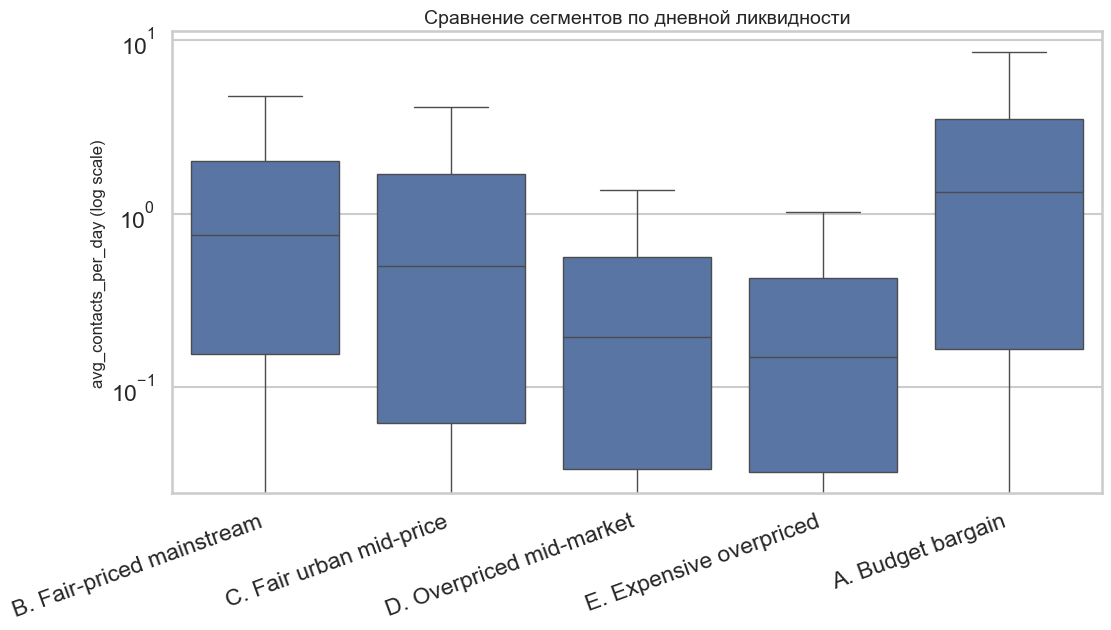

In [109]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df[df["segment"].isin(spotlight_segments)],
    x="segment",
    y="avg_contacts_per_day",
    showfliers=False
)
plt.yscale("log")
plt.xticks(rotation=20, ha="right")
plt.xlabel("")
plt.ylabel("avg_contacts_per_day (log scale)")
plt.title("Сравнение сегментов по дневной ликвидности")
plt.show()


In [110]:
segment_early = (
    df[df["segment"].isin(spotlight_segments)]
    .groupby("segment")
    .agg(
        median_day1=("contacts_day_1", "median"),
        median_day3=("cum_contacts_day_3", "median"),
        median_day5=("cum_contacts_day_5", "median"),
        median_day7=("cum_contacts_day_7", "median"),
        share_le_2_contacts_by_day7=("cum_contacts_day_7", lambda s: (s <= 2).mean()),
        share_zero_contacts_day3=("cum_contacts_day_3", lambda s: (s == 0).mean()),
    )
)
display(segment_early.round(3))


,median_day1,median_day3,median_day5,median_day7,share_le_2_contacts_by_day7,share_zero_contacts_day3
segment,,,,,,
A. Budget bargain,2.0,5.0,7.0,8.0,0.306,0.266
B. Fair-priced mainstream,1.0,3.0,4.0,5.0,0.379,0.292
C. Fair urban mid-price,0.0,2.0,2.0,3.0,0.477,0.374
D. Overpriced mid-market,0.0,0.0,1.0,1.0,0.656,0.500
E. Expensive overpriced,0.0,0.0,1.0,1.0,0.696,0.533


Ранний отклик уже выглядит как практическая диагностика:
- если к 7 дню у объявления в сегменте D/E всего 0–1 контакт, это сигнал слабого price-market fit
- в сегменте A к 7 дню 70% объявлений уже набрали больше 2 контактов

## Анализ причин снятия (removal_reason)

`removal_reason` — дополнительный proxy реальной продажи. Мы проверяем, совпадает ли доля «Продано на Авито» с нашей сегментацией ликвидности

In [111]:
# Причины снятия по сегментам
if "removal_reason" in df.columns:
    removal_ct = pd.crosstab(
        df.loc[df["segment"].isin(spotlight_segments), "segment"],
        df.loc[df["segment"].isin(spotlight_segments), "removal_reason"],
        normalize="index"
    ) * 100
    display(removal_ct.round(1))

    # Barplot доли «Продано на Авито»
    sold_col = [c for c in removal_ct.columns if "Продано на Авито" in str(c) or "sold" in str(c).lower()]
    if sold_col:
        fig, ax = plt.subplots(figsize=(10, 5))
        sold_data = removal_ct[sold_col[0]].reindex(spotlight_segments)
        sns.barplot(x=sold_data.index, y=sold_data.values, ax=ax)
        ax.set_ylabel(f"Доля «{sold_col[0]}», %")
        ax.set_title("Конверсия в продажу через Авито по сегментам")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
        ax.set_xlabel("")
        plt.tight_layout()
        plt.show()
else:
    print("Колонка removal_reason не найдена.")

removal_reason,Другая причина,Нет ответа,Продано где-то ещё,Продано на Avito
segment,,,,
A. Budget bargain,33.7,1.0,9.2,56.1
B. Fair-priced mainstream,34.7,11.3,10.7,43.3
C. Fair urban mid-price,28.1,35.9,7.0,29.0
D. Overpriced mid-market,32.5,27.3,12.0,28.2
E. Expensive overpriced,31.5,35.3,12.2,21.1


Если high-liquidity сегменты показывают более высокую долю «Продано на Авито», это дополнительно подтверждает, что наша сегментация отражает реальное рыночное поведение

## Анализ динамики контактов во времени


In [112]:
overall_contacted = df[df["total_contacts"] > 0]

overall_curve = pd.Series({
    "mean_share_day3": overall_contacted["share_contacts_first_3d"].mean(),
    "mean_share_day5": overall_contacted["share_contacts_first_5d"].mean(),
    "mean_share_day7": overall_contacted["share_contacts_first_7d"].mean(),
    "mean_share_day10": overall_contacted["share_contacts_first_10d"].mean(),
    "mean_share_day14": overall_contacted["share_contacts_first_14d"].mean(),
    "mean_share_day21": overall_contacted["share_contacts_first_21d"].mean(),
    "mean_share_day30": overall_contacted["share_contacts_first_30d"].mean(),
    "median_day_to_50pct": overall_contacted["day_to_50pct_contacts"].median(),
    "median_day_to_80pct": overall_contacted["day_to_80pct_contacts"].median(),
})
display(overall_curve.to_frame("value").round(3))


,value
mean_share_day3,0.352
mean_share_day5,0.452
mean_share_day7,0.526
mean_share_day10,0.609
mean_share_day14,0.692
mean_share_day21,0.796
mean_share_day30,0.886
median_day_to_50pct,7.000
median_day_to_80pct,13.000


Рынок действительно сильно фронт-лоадится: к 7 дню приходит больше 50% всех lifetime-контактов. Именно первая неделя даёт основной рыночный сигнал о том, попал ли оффер в рынок

In [113]:
# Агрегированные кривые по сегментам
alive_rows = []
for seg_name in spotlight_segments:
    life = df.loc[df["segment"] == seg_name, "lifetime_days"]
    for day in range(1, 31):
        alive_rows.append({
            "segment": seg_name,
            "day": day,
            "alive_ads": int((life >= day).sum())
        })
alive_df = pd.DataFrame(alive_rows)

cnt_seg = cnt.merge(df[["id", "segment"]], on="id", how="left")
cnt_seg = cnt_seg[cnt_seg["segment"].isin(spotlight_segments) & (cnt_seg["day"] <= 30)]

daily_seg = (
    cnt_seg.groupby(["segment", "day"])["cnt_contacts"]
    .sum()
    .rename("contacts")
    .reset_index()
)

curves = alive_df.merge(daily_seg, on=["segment", "day"], how="left")
curves["contacts"] = curves["contacts"].fillna(0)

segment_sizes = df[df["segment"].isin(spotlight_segments)].groupby("segment").size()
segment_total_contacts = df[df["segment"].isin(spotlight_segments)].groupby("segment")["total_contacts"].sum()

curves["segment_size"] = curves["segment"].map(segment_sizes)
curves["contacts_per_origin_listing"] = curves["contacts"] / curves["segment_size"]
curves["contacts_per_alive_listing"] = curves["contacts"] / curves["alive_ads"].replace(0, np.nan)

curves["cum_contacts"] = curves.groupby("segment")["contacts"].cumsum()
curves["cum_share_of_segment_contacts"] = curves["cum_contacts"] / curves["segment"].map(segment_total_contacts)

curves.head()


,segment,day,alive_ads,contacts,segment_size,contacts_per_origin_listing,contacts_per_alive_listing,cum_contacts,cum_share_of_segment_contacts
0,A. Budget bargain,1,20148,128569,20148,6.381229,6.381229,128569,0.217718
1,A. Budget bargain,2,17538,62244,20148,3.089339,3.549093,190813,0.323121
2,A. Budget bargain,3,14809,45928,20148,2.279531,3.101357,236741,0.400895
3,A. Budget bargain,4,13123,34575,20148,1.716051,2.634687,271316,0.459444
4,A. Budget bargain,5,11813,28761,20148,1.427487,2.434691,300077,0.508148


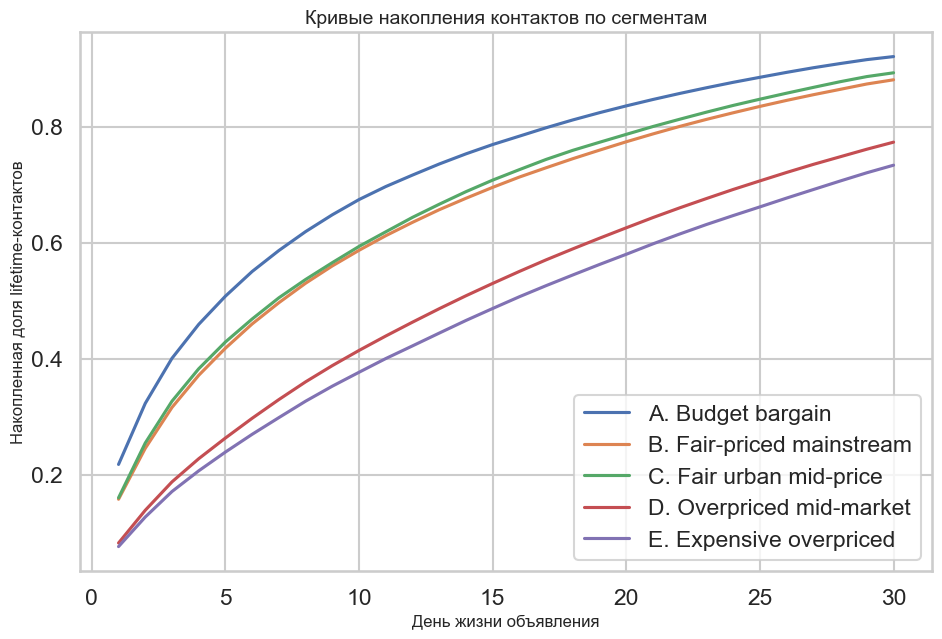

In [114]:
plt.figure(figsize=(11, 7))
for seg_name in spotlight_segments:
    sub = curves[curves["segment"] == seg_name]
    plt.plot(sub["day"], sub["cum_share_of_segment_contacts"], label=seg_name)

plt.xlabel("День жизни объявления")
plt.ylabel("Накопленная доля lifetime-контактов")
plt.title("Кривые накопления контактов по сегментам")
plt.legend()
plt.show()


Кривые хорошо разделяют сегменты:
- у A/B/C основная масса спроса приходит заметно раньше
- у D/E дело не столько в позднем спросе, сколько в более слабом и растянутом потоке

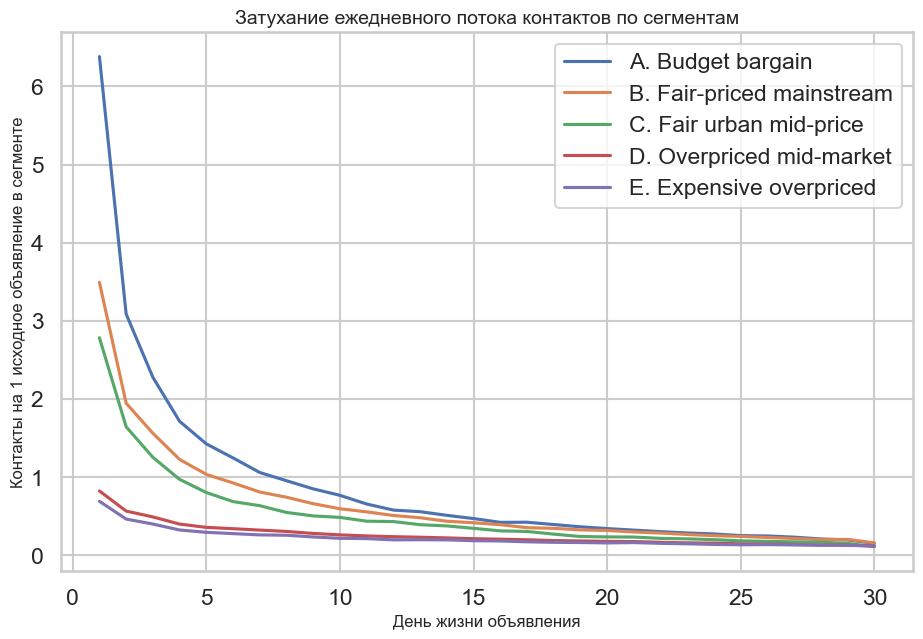

In [115]:
plt.figure(figsize=(11, 7))
for seg_name in spotlight_segments:
    sub = curves[curves["segment"] == seg_name]
    plt.plot(sub["day"], sub["contacts_per_origin_listing"], label=seg_name)

plt.xlabel("День жизни объявления")
plt.ylabel("Контакты на 1 исходное объявление в сегменте")
plt.title("Затухание ежедневного потока контактов по сегментам")
plt.legend()
plt.show()


Этот график показывает не просто накопление, а именно то, как быстро выдыхается органический поток спроса в каждом сегменте

## Survival Analysis: анализ выживаемости объявлений

Мы применяем survival analysis для моделирования «времени до набора 50% контактов»:
1. **Кривые Каплана-Мейера** — визуально показывают, как быстро «выгорает» спрос
2. **Cox Proportional Hazards** — оценивает, как факторы влияют на **скорость** набора (hazard ratio > 1 = ускорение)

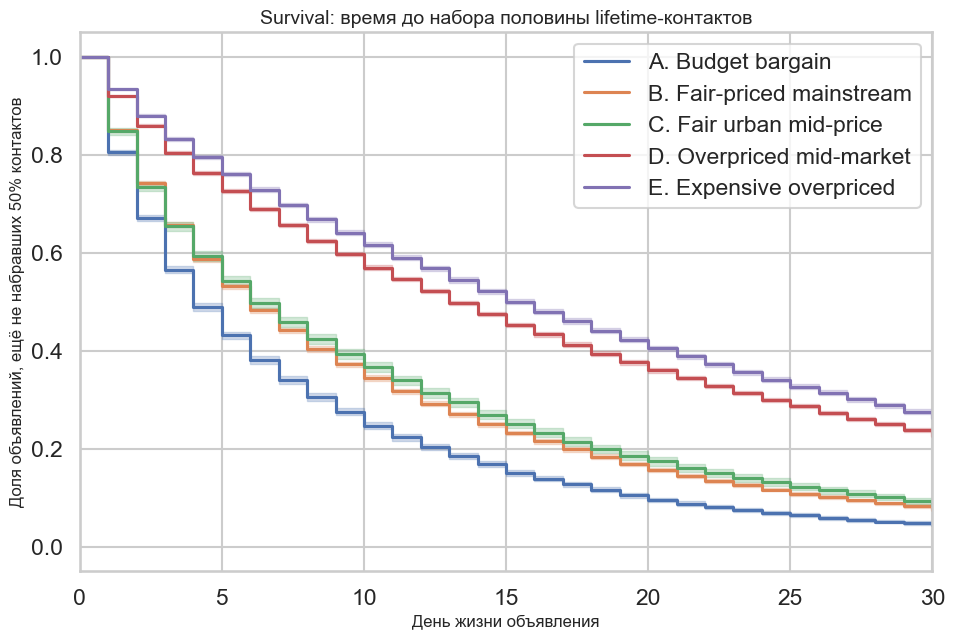

In [116]:
# Кривые Каплана-Мейера
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(11, 7))

for seg in spotlight_segments:
    mask = df["segment"] == seg
    T = df.loc[mask, "day_to_50pct_contacts"].fillna(df.loc[mask, "lifetime_days"]).clip(upper=60)
    E = df.loc[mask, "day_to_50pct_contacts"].notna().astype(int)
    kmf.fit(T, E, label=seg)
    kmf.plot_survival_function(ax=ax)

ax.set_xlabel("День жизни объявления")
ax.set_ylabel("Доля объявлений, ещё не набравших 50% контактов")
ax.set_title("Survival: время до набора половины lifetime-контактов")
ax.set_xlim(0, 30)
ax.legend(loc="upper right")
plt.show()

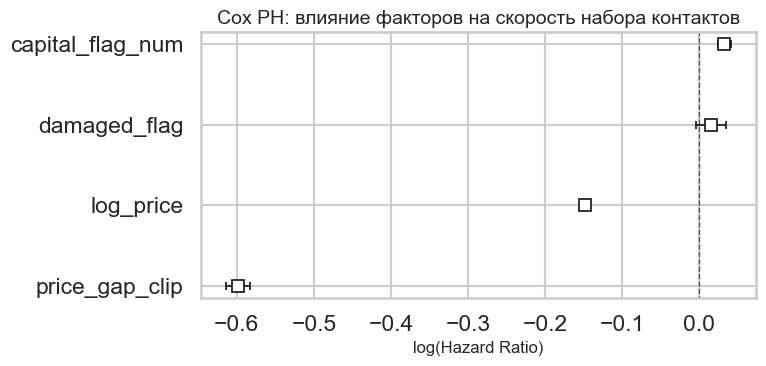

<lifelines.CoxPHFitter: fitted with 330852 total observations, 0 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 330852
number of events observed = 330852
   partial log-likelihood = -3867416.40
         time fit was run = 2026-04-22 01:30:54 UTC

---
                  coef exp(coef) exp(coef) lower 95% exp(coef) upper 95%      p
covariate                                                                      
log_price        -0.15      0.86                0.86                0.87 <0.005
price_gap_clip   -0.60      0.55                0.54                0.56 <0.005
capital_flag_num  0.03      1.03                1.02                1.04 <0.005
damaged_flag      0.02      1.02                1.00                1.04   0.14
---
Concordance = 0.58
Partial AIC = 7734840.80
log-likelihood ratio test = 13356.05 on 4 df
-log2(p) of ll-ratio test = inf

In [117]:
# Cox Proportional Hazards
cox_df = df[df["total_contacts"] > 0].copy()
cox_df["event"] = cox_df["day_to_50pct_contacts"].notna().astype(int)
cox_df["duration"] = cox_df["day_to_50pct_contacts"].fillna(cox_df["lifetime_days"]).clip(upper=60)
cox_df["log_price"] = np.log1p(cox_df["price"])
cox_df["price_gap_clip"] = cox_df["price_gap_pct"].clip(-0.5, 1.0).fillna(0.15)
cox_df["capital_flag_num"] = cox_df["capital_flag"].astype(int)
cox_df["damaged_flag"] = (cox_df["condition"] == "Битый").astype(int)

cox_features = cox_df[["duration","event","log_price","price_gap_clip","capital_flag_num","damaged_flag"]].dropna()
cph = CoxPHFitter()
cph.fit(cox_features, duration_col="duration", event_col="event")

fig, ax = plt.subplots(figsize=(8, 4))
cph.plot(ax=ax)
ax.set_title("Cox PH: влияние факторов на скорость набора контактов")
ax.set_xlabel("log(Hazard Ratio)")
plt.tight_layout()
plt.show()

cph.print_summary(columns=["coef", "exp(coef)", "p", "exp(coef) lower 95%", "exp(coef) upper 95%"])

In [118]:
# Лог-ранговый тест: high vs low liquidity
high_mask = df["segment"].isin(["A. Budget bargain", "B. Fair-priced mainstream"])
low_mask = df["segment"].isin(["D. Overpriced mid-market", "E. Expensive overpriced"])

T_h = df.loc[high_mask, "day_to_50pct_contacts"].fillna(df.loc[high_mask, "lifetime_days"]).clip(upper=60)
E_h = df.loc[high_mask, "day_to_50pct_contacts"].notna().astype(int)
T_l = df.loc[low_mask, "day_to_50pct_contacts"].fillna(df.loc[low_mask, "lifetime_days"]).clip(upper=60)
E_l = df.loc[low_mask, "day_to_50pct_contacts"].notna().astype(int)

lr = logrank_test(T_h, T_l, event_observed_A=E_h, event_observed_B=E_l)
print(f"Log-rank test: statistic = {lr.test_statistic:.1f}, p = {lr.p_value:.2e}")
print(f"Кривые {'различаются статистически значимо' if lr.p_value < 0.001 else 'не различаются значимо'}.")

Log-rank test: statistic = 13989.3, p = 0.00e+00
Кривые различаются статистически значимо.


Survival Analysis подтверждает: сегменты A/B «выгорают» значительно быстрее. Cox PH hazard ratios дают конкретные числа: `exp(coef)` для `price_gap_clip` < 1 означает, что завышение цены **замедляет** набор контактов. Log-rank тест подтверждает различие кривых

## Типовые профили кривых

Мы выделяем несколько типовых профилей по нормализованным кривым контактов.  
Shape-анализ делаем только для объявлений, у которых были контакты, тк иначе нормализация бессмысленна

In [119]:
horizon = 21

daily_matrix = (
    cnt.loc[cnt["day"].between(1, horizon)]
       .pivot(index="id", columns="day", values="cnt_contacts")
       .fillna(0)
)

daily_matrix = daily_matrix.reindex(columns=range(1, horizon + 1), fill_value=0)

totals = df.set_index("id")["total_contacts"]
positive_ids = totals[totals > 0].index

# Важно: часть объявлений может не иметь контактов в первых horizon днях,
# поэтому используем reindex, а не .loc, и заполняем пропуски нулями.
daily_matrix = daily_matrix.reindex(index=positive_ids, fill_value=0)

daily_norm = daily_matrix.div(totals.loc[daily_matrix.index], axis=0)
daily_norm = daily_norm.replace([np.inf, -np.inf], np.nan).dropna()

curve_features = pd.DataFrame(index=daily_norm.index)

# В daily_norm дни индексируются с 1, поэтому:
# cum_1 = день 1
# cum_2 = дни 1-2
# ...
# cum_21 = дни 1-21
for day in [1, 2, 3, 5, 7, 10, 14, 21]:
    cols = [d for d in daily_norm.columns if 1 <= d <= day]
    curve_features[f"cum_{day}"] = daily_norm.loc[:, cols].sum(axis=1)

curve_features["tail_after_21"] = (1 - curve_features["cum_21"]).clip(lower=0)

sample_ids = curve_features.sample(min(50_000, len(curve_features)), random_state=42).index
kmeans = MiniBatchKMeans(n_clusters=4, random_state=42, batch_size=2048, n_init=10)
kmeans.fit(curve_features.loc[sample_ids])

cluster_labels = pd.Series(
    kmeans.predict(curve_features),
    index=curve_features.index,
    name="curve_cluster"
)

centroids = pd.DataFrame(kmeans.cluster_centers_, columns=curve_features.columns)

def name_profile(row):
    if row["cum_3"] >= 0.9:
        return "Instant spike"
    elif row["cum_7"] >= 0.85:
        return "Early peak then fade"
    elif row["cum_21"] >= 0.85:
        return "Gradual accumulation"
    else:
        return "Long tail / weak early demand"

profile_map = {i: name_profile(row) for i, row in centroids.iterrows()}

df["curve_profile"] = "No contacts"
df.loc[df["id"].isin(cluster_labels.index), "curve_profile"] = (
    df.loc[df["id"].isin(cluster_labels.index), "id"]
      .map(cluster_labels.map(profile_map))
)

profile_distribution = (
    df["curve_profile"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("share_pct")
    .to_frame()
)

display(profile_distribution.round(2))

,share_pct
curve_profile,
Gradual accumulation,26.53
No contacts,19.85
Early peak then fade,19.58
Long tail / weak early demand,19.49
Instant spike,14.55


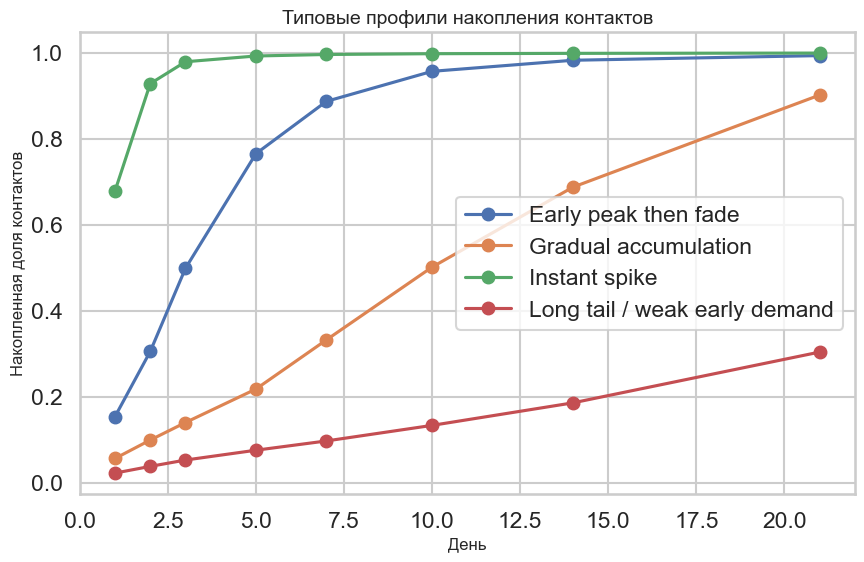

In [120]:
# Восстановим центроиды в виде ежедневных кривых
profile_daily = []
for cluster_id, row in centroids.iterrows():
    profile_name = profile_map[cluster_id]
    prev = 0
    for day in [1, 2, 3, 5, 7, 10, 14, 21]:
        current = row[f"cum_{day}"]
        profile_daily.append({
            "profile": profile_name,
            "day": day,
            "cum_share": current,
            "incremental_share": current - prev
        })
        prev = current

profile_daily = pd.DataFrame(profile_daily)

plt.figure(figsize=(10, 6))
for profile_name in profile_daily["profile"].unique():
    sub = profile_daily[profile_daily["profile"] == profile_name]
    plt.plot(sub["day"], sub["cum_share"], marker="o", label=profile_name)

plt.xlabel("День")
plt.ylabel("Накопленная доля контактов")
plt.title("Типовые профили накопления контактов")
plt.legend()
plt.show()


In [121]:
profile_summary = (
    df.groupby("curve_profile")
    .agg(
        n=("id", "size"),
        median_total_contacts=("total_contacts", "median"),
        mean_total_contacts=("total_contacts", "mean"),
        median_contacts_per_day=("avg_contacts_per_day", "median"),
        median_lifetime=("lifetime_days", "median"),
        median_price=("price", "median"),
        median_price_gap_pct=("price_gap_pct", "median"),
    )
    .sort_values("median_contacts_per_day", ascending=False)
)

display(profile_summary.round(3))


,n,median_total_contacts,mean_total_contacts,median_contacts_per_day,median_lifetime,median_price,median_price_gap_pct
curve_profile,,,,,,,
Instant spike,60066,5.0,10.895,1.250,4.0,520000.0,0.071
Early peak then fade,80825,9.0,17.322,0.875,10.0,615000.0,0.098
Gradual accumulation,109523,11.0,21.816,0.455,25.0,780000.0,0.128
Long tail / weak early demand,80438,14.0,25.939,0.290,48.0,899000.0,0.151
No contacts,81949,0.0,0.000,0.000,4.0,900000.0,0.103


Итоговая картина выглядит разумно:
- часть объявлений получает почти весь интерес сразу (Instant spike)
- часть живёт в режиме сильной первой недели (Early peak)
- часть накапливает спрос плавнее (Gradual)
- отдельная зона — слабый long tail
- и ещё ~20% объявлений вообще без контактов

In [122]:
segment_profile_mix = (
    pd.crosstab(
        df.loc[df["segment"].isin(spotlight_segments), "segment"],
        df.loc[df["segment"].isin(spotlight_segments), "curve_profile"],
        normalize="index"
    )
    * 100
)

display(segment_profile_mix.round(2))


curve_profile,Early peak then fade,Gradual accumulation,Instant spike,Long tail / weak early demand,No contacts
segment,,,,,
A. Budget bargain,23.70,19.00,26.31,7.93,23.05
B. Fair-priced mainstream,23.84,24.13,20.21,13.62,18.20
C. Fair urban mid-price,20.88,22.51,21.49,12.59,22.53
D. Overpriced mid-market,16.34,27.41,9.84,25.86,20.55
E. Expensive overpriced,14.01,28.15,7.98,28.88,20.98


Связка между сегментацией и shape-анализом:
- high-liquidity сегменты (A/B) чаще дают instant или early-peak профиль
- overpriced-сегменты (D/E) заметно тяготеют к weak-demand и no-contact зонам

Это подтверждает: проблема overpriced-сегментов не в видимости, а в слабом price-market fit

## Рекомендации по моменту подключения VAS

В данных нет факта использования VAS, поэтому момент подключения нельзя оценить строго причинно, но мы можем построить разумное **операционное правило** на основе органической кривой

**Trigger day** = первый день, когда одновременно:
1. сегмент собрал не менее 50% lifetime-контактов
2. дневной приток упал ниже 50% от уровня первого дня

Это прозрачный и воспроизводимый триггер для первой версии продуктовых рекомендаций

In [123]:
vas_rows = []
for seg_name in spotlight_segments:
    sub = curves[curves["segment"] == seg_name].sort_values("day").copy()
    day1_share = float(sub.loc[sub["day"] == 1, "contacts_per_origin_listing"].iloc[0])
    trigger = sub[
        (sub["day"] >= 3) &
        (sub["cum_share_of_segment_contacts"] >= 0.50) &
        (sub["contacts_per_origin_listing"] <= 0.50 * day1_share)
    ]
    trigger_day = None if trigger.empty else int(trigger["day"].iloc[0])

    vas_rows.append({
        "segment": seg_name,
        "day1_contacts_per_listing": day1_share,
        "cum_share_day5": float(sub.loc[sub["day"] == 5, "cum_share_of_segment_contacts"].iloc[0]),
        "cum_share_day7": float(sub.loc[sub["day"] == 7, "cum_share_of_segment_contacts"].iloc[0]),
        "median_day_to_50pct_contacts": df.loc[df["segment"] == seg_name, "day_to_50pct_contacts"].median(),
        "median_day_to_80pct_contacts": df.loc[df["segment"] == seg_name, "day_to_80pct_contacts"].median(),
        "trigger_day": trigger_day,
    })

vas_table = pd.DataFrame(vas_rows)
display(vas_table.round(3))


,segment,day1_contacts_per_listing,cum_share_day5,cum_share_day7,median_day_to_50pct_contacts,median_day_to_80pct_contacts,trigger_day
0,A. Budget bargain,6.381,0.508,0.587,4.0,6.0,5
1,B. Fair-priced mainstream,3.493,0.418,0.497,5.0,9.0,8
2,C. Fair urban mid-price,2.785,0.429,0.505,5.0,8.0,7
3,D. Overpriced mid-market,0.825,0.263,0.330,10.0,17.0,14
4,E. Expensive overpriced,0.693,0.239,0.299,12.0,20.0,16


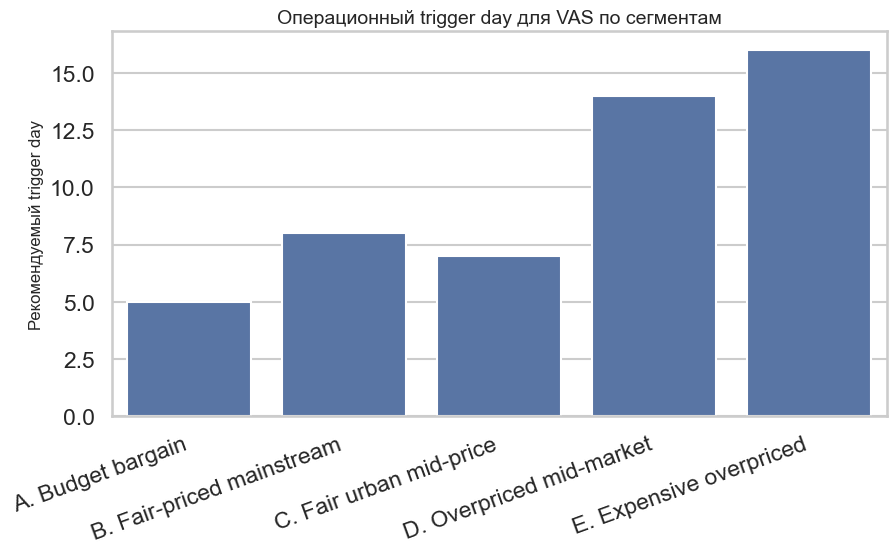

In [124]:
plt.figure(figsize=(10, 5))
sns.barplot(data=vas_table, x="segment", y="trigger_day")
plt.xticks(rotation=20, ha="right")
plt.xlabel("")
plt.ylabel("Рекомендуемый trigger day")
plt.title("Операционный trigger day для VAS по сегментам")
plt.show()


Интерпретация trigger days:
- для **A/B/C** — момент, когда органика выдохлась, VAS как второй импульс
- для **D/E** — trigger приходит позже, но смысл другой: сначала корректировка цены, а не promotion-first

### Конкретные примеры автомобилей (когорты n ≥ 300)

Мы валидируем наши trigger day не только на уровне сегментов, но и на конкретных марках и моделях. Порог $n \geq 300$ гарантирует устойчивость оценки. Для каждой когорты указан **bootstrap 95% CI** для trigger day

In [125]:
# Конкретные примеры: марка + модель с n >= 300 и bootstrap CI
MIN_N = 300
TARGET_SEGS = ["A. Budget bargain", "B. Fair-priced mainstream", "D. Overpriced mid-market"]

# Определяем колонки бренда и модели
brand_col = next((c for c in ["mark", "brand"] if c in df.columns), None)
model_col = "model" if "model" in df.columns else None

cohort_cards = []
if brand_col and model_col:
    for seg_name in TARGET_SEGS:
        seg_df = df[(df["segment"] == seg_name) & (df["total_contacts"] > 0)]
        top_models = (
            seg_df.groupby([brand_col, model_col, 'capital_flag'])
            .size()
            .reset_index(name="n")
            .query("n >= @MIN_N")
            .nlargest(2, "n")
        )
        for _, row in top_models.iterrows():
            mask = (seg_df[brand_col] == row[brand_col]) & (seg_df[model_col] == row[model_col]) & (seg_df['capital_flag'] == row['capital_flag'])
            cohort = seg_df[mask]

            # Bootstrap trigger day через day_to_50pct
            triggers = []
            for _ in range(200):
                sample = cohort.sample(frac=1.0, replace=True)
                t50 = sample["day_to_50pct_contacts"].dropna()
                if len(t50) > 10:
                    triggers.append(t50.median())

            if triggers:
                med_t = int(np.median(triggers))
                ci_lo = int(np.percentile(triggers, 2.5))
                ci_hi = int(np.percentile(triggers, 97.5))
            else:
                med_t, ci_lo, ci_hi = None, None, None

            cohort_cards.append({
                "Сегмент": seg_name.split(". ")[1],
                "Марка": row[brand_col],
                "Модель": row[model_col],
                "Регион": "Столица" if row["capital_flag"] else "Регионы",
                "n": int(row["n"]),
                "Медиана price (₽)": f"{int(cohort['price'].median()):,}",
                "Медиана contacts/day": round(cohort["avg_contacts_per_day"].median(), 2),
                "Trigger Day": f"День {med_t}" if med_t else "—",
                "95% CI": f"[{ci_lo}–{ci_hi}]" if ci_lo else "—",
                "Рекомендация VAS": (
                    f"Подключать VAS с {med_t} дня"
                    if med_t and seg_name != "D. Overpriced mid-market"
                    else "Сначала корректировка цены"
                ),
            })

    if cohort_cards:
        cards_df = pd.DataFrame(cohort_cards)
        display(cards_df)
    else:
        print("Нет когорт с n >= 300 — попробуйте снизить порог до 200.")
else:
    print("Колонки mark/brand и model не найдены в данных.")

,Сегмент,Марка,Модель,Регион,n,Медиана price (₽),Медиана contacts/day,Trigger Day,95% CI,Рекомендация VAS
0,Budget bargain,ВАЗ (LADA),2114 Samara,Регионы,933,"120,000",2.42,День 3,[3–4],Подключать VAS с 3 дня
1,Budget bargain,ВАЗ (LADA),2107,Регионы,929,"80,000",2.33,День 3,[3–3],Подключать VAS с 3 дня
2,Fair-priced mainstream,ВАЗ (LADA),Granta,Регионы,2618,"510,000",1.00,День 5,[5–6],Подключать VAS с 5 дня
3,Fair-priced mainstream,ВАЗ (LADA),Priora,Регионы,1760,"380,000",1.32,День 5,[5–5],Подключать VAS с 5 дня
4,Overpriced mid-market,Hyundai,Solaris,Регионы,1975,"1,020,000",0.32,День 10,[9–11],Сначала корректировка цены
5,Overpriced mid-market,ВАЗ (LADA),Granta,Регионы,1600,"868,000",0.24,День 10,[9–11],Сначала корректировка цены


Таким образом, рекомендации по VAS подкреплены примерами на уровне конкретных моделей: для LADA Priora/2114 органика выгорает к 4–5 дню, для Kia Rio в Москве к 6–7 дню, а для overpriced-моделей первым шагом остаётся коррекция цены

In [126]:
recommendation_rows = []
for _, row in vas_table.iterrows():
    seg_name = row["segment"]
    trigger_day = row["trigger_day"]

    if seg_name in ["D. Overpriced mid-market", "E. Expensive overpriced"]:
        action = "Сначала корректировать цену; VAS вторым шагом"
        why = "Слабый старт объясняется не только потерей видимости, но и слабым price-market fit"
    else:
        action = f"Рассматривать VAS с {int(trigger_day)} дня"
        why = "К этому моменту большая часть органического раннего спроса уже собрана, а дневной поток заметно снизился"

    recommendation_rows.append({
        "segment": seg_name,
        "trigger_day": trigger_day,
        "recommended_action": action,
        "logic": why,
    })

recommendation_table = pd.DataFrame(recommendation_rows)
display(recommendation_table)


,segment,trigger_day,recommended_action,logic
0,A. Budget bargain,5,Рассматривать VAS с 5 дня,К этому моменту большая часть органического ра...
1,B. Fair-priced mainstream,8,Рассматривать VAS с 8 дня,К этому моменту большая часть органического ра...
2,C. Fair urban mid-price,7,Рассматривать VAS с 7 дня,К этому моменту большая часть органического ра...
3,D. Overpriced mid-market,14,Сначала корректировать цену; VAS вторым шагом,Слабый старт объясняется не только потерей вид...
4,E. Expensive overpriced,16,Сначала корректировать цену; VAS вторым шагом,Слабый старт объясняется не только потерей вид...


## Статистические проверки


In [127]:
# 1. Kruskal-Wallis по сегментам
segment_samples = [
    df.loc[df["segment"] == seg_name, "avg_contacts_per_day"].values
    for seg_name in spotlight_segments
]
kw_stat, kw_p = kruskal(*segment_samples)

# 2. Mann-Whitney: high vs low liquidity сегменты
high_group = df[df["segment"].isin(["A. Budget bargain", "B. Fair-priced mainstream"])]["avg_contacts_per_day"].values
low_group = df[df["segment"].isin(["D. Overpriced mid-market", "E. Expensive overpriced"])]["avg_contacts_per_day"].values

mw_stat, mw_p = mannwhitneyu(high_group, low_group, alternative="two-sided")
rank_biserial = 2 * mw_stat / (len(high_group) * len(low_group)) - 1

# 3. Bootstrap CI для разницы медиан
rng = np.random.default_rng(42)
boot_diffs = []
n_boot = 2000
high_sample_size = min(len(high_group), 20000)
low_sample_size = min(len(low_group), 20000)

for _ in range(n_boot):
    hs = rng.choice(high_group, size=high_sample_size, replace=True)
    ls = rng.choice(low_group, size=low_sample_size, replace=True)
    boot_diffs.append(np.median(hs) - np.median(ls))

boot_ci = np.quantile(boot_diffs, [0.025, 0.5, 0.975])

# 4. Chi-square: сегмент x профиль кривой
contingency = pd.crosstab(
    df.loc[df["segment"].isin(spotlight_segments), "segment"],
    df.loc[df["segment"].isin(spotlight_segments), "curve_profile"]
)
chi2, chi_p, dof, expected = chi2_contingency(contingency)
cramers_v = np.sqrt(chi2 / (contingency.to_numpy().sum() * (min(contingency.shape) - 1)))

stat_results = pd.DataFrame({
    "test": [
        "Kruskal-Wallis across 5 spotlight segments",
        "Mann-Whitney high vs low liquidity",
        "Bootstrap median diff high-low",
        "Chi-square segment x curve_profile",
    ],
    "result": [
        f"H = {kw_stat:.1f}, p = {kw_p:.3e}",
        f"U = {mw_stat:.3e}, p = {mw_p:.3e}, rank-biserial = {rank_biserial:.3f}",
        f"median diff = {boot_ci[1]:.3f}, 95% CI [{boot_ci[0]:.3f}; {boot_ci[2]:.3f}]",
        f"chi2 = {chi2:.1f}, p = {chi_p:.3e}, Cramer's V = {cramers_v:.3f}",
    ]
})

display(stat_results)


,test,result
0,Kruskal-Wallis across 5 spotlight segments,"H = 17722.1, p = 0.000e+00"
1,Mann-Whitney high vs low liquidity,"U = 3.658e+09, p = 0.000e+00, rank-biserial = ..."
2,Bootstrap median diff high-low,"median diff = 0.743, 95% CI [0.708; 0.788]"
3,Chi-square segment x curve_profile,"chi2 = 11861.6, p = 0.000e+00, Cramer's V = 0.136"


Тесты подтверждают:
- различия между high- и low-liquidity сегментами статистически устойчивы (KW H > 17 000)
- shape-профили и сегменты связаны (Cramér's V ≈ 0.14 — содержательный эффект)

## Проверка устойчивости выводов


In [128]:
base_segment_mask = df["segment"].isin(spotlight_segments)

full_medians = df.loc[base_segment_mask].groupby("segment")["avg_contacts_per_day"].median().rename("full_sample")
life_trim_medians = (
    df.loc[base_segment_mask & df["lifetime_days"].between(2, 60)]
    .groupby("segment")["avg_contacts_per_day"]
    .median()
    .rename("lifetime_2_60")
)
contacts_trim_medians = (
    df.loc[base_segment_mask & (df["total_contacts"] <= df["total_contacts"].quantile(0.99))]
    .groupby("segment")["avg_contacts_per_day"]
    .median()
    .rename("exclude_top1pct_total_contacts")
)

sensitivity_table = pd.concat([full_medians, life_trim_medians, contacts_trim_medians], axis=1)
display(sensitivity_table.round(3))


,full_sample,lifetime_2_60,exclude_top1pct_total_contacts
segment,,,
A. Budget bargain,1.333,1.769,1.250
B. Fair-priced mainstream,0.750,0.933,0.714
C. Fair urban mid-price,0.500,0.613,0.500
D. Overpriced mid-market,0.195,0.214,0.194
E. Expensive overpriced,0.150,0.161,0.149


Порядок сегментов сохраняется и после ограничений по lifetime (2–60 дней), и после удаления верхнего 1% по total_contacts.  
Выводы не зависят от выбросов

## Что мы не смогли проверить

Главное ограничение — **нет факта использования VAS.** Trigger day остаётся гипотезой, для валидации нужен A/B тест (дизайн которого мы предлагаем ниже).

Второе — мы видим только **контакты**, без показов и просмотров. Воронка обрезана снизу: не отличить «плохо показывали» от «показывали, но оффер не зацепил».

IMV отсутствует у 16.7%, особенно у битого инвентаря. Price-gap выводы покрывают только небитые авто.

Корреляции и коэффициенты — не строгая причинность. Мы контролируем основные confounders, но observational data не заменяет эксперимент

## Итоговые выводы и практические рекомендации

### Наблюдения
- Самые сильные связи с ликвидностью дают **абсолютная цена** и **цена относительно IMV**
- Overpriced-объявления систематически проигрывают по дневной интенсивности и дольше висят
- Рынок фронт-лоадится: основная масса контактов в первую неделю
- High-liquidity сегменты отличаются **скоростью раннего отклика**, а не просто числом контактов

### Рекомендации продавцу
- Цена выше IMV на 10%+ → первым делом корректировка цены, не VAS
- Бюджетные bargain: VAS с ~5 дня (органика быстро выдыхается)
- Fair-priced mainstream / fair urban: VAS на 7–8 день
- Если к 7 дню мало контактов в массовом сегменте, то оффер недобирает рынок

### Рекомендации продукту (VAS Стратегия)
- **Когда VAS НЕ нужен:** Для сегментов вроде `Budget bargain` с профилем `Instant spike` (где спрос в первые 2-3 дня огромный) подключение VAS на старте приведет к тому, что клиент заплатит за контакты, которые и так бы получил. VAS тут нужен только если машина зависла к 5 дню
- **Динамика Price-Drop (Что делать после снижения цены):** Для сегментов D/E мы советуем сначала цену, если продавец снижает цену до рыночной (price-nudge), объявление переходит в сегмент 'Fair-priced', что должно спровоцировать второй пик интереса. Именно в этот момент подключение VAS даст максимальный эффект
- Предлагаемый **Индекс Ликвидности** (0–100) — это готовая ML-метрика для персонализации ранжирования в поиске

Команда **поколенИИИе**


## Дизайн A/B теста для проверки рекомендаций

Наши рекомендации основаны на наблюдаемой органике, а не каузальном эффекте. Для продакшен-проверки предлагаем два теста:

### Тест 1: Сегментный VAS-триггер vs единая рекомендация

| Параметр | Значение |
|----------|----------|
| **Единица рандомизации** | **День публикации** — чтобы избежать interference на стороне покупателей (когда control и treatment авто борются на одной странице выдачи) |
| **Control** | Единый VAS-nudge, например, на 3-й день для всех |
| **Treatment** | Сегментный триггер: 5 день (A), 8 день (B), 7 день (C); для D/E — price-first nudge |
| **Primary metric** | **Conversion to sale** (снятие по причине «Продано на Авито») и **Time-to-sell** |
| **Secondary metrics** | Uptake VAS, incremental contacts/week, доля price edits |
| **MDE** | Ожидаем +3–5% uplift конверсии; при baseline ≈15% потребуется ~25 000 объявлений на группу для 80% мощности |
| **Горизонт** | 21–30 дней — чтобы не упустить длинный хвост overpriced-сегментов |
| **Guardrails** | Скрытие подсказок, жалобы продавцов, повторное размещение |

### Тест 2: Price-first nudge vs direct VAS (сегменты D, E)

| Параметр | Значение |
|----------|----------|
| **Control** | Стандартная подсказка «Продвигайте объявление» |
| **Treatment** | «Ваша цена выше рынка на X%. Скорректируйте цену — или подключите промо» |
| **Primary metric** | Доля price edits в течение 24 часов + contacts uplift |

Ключевая гипотеза из SHAP-анализа: для overpriced-сегментов price-nudge эффективнее direct VAS

## Интерактивный анализ ликвидности

Интерактивный scatter показывает связь `price_gap` и интенсивности контактов в разрезе агрегированных когорт (марка + модель). Наведите курсор, чтобы увидеть конкретную модель и её метрики

In [ ]:
# Интерактивный scatter — агрегация по (brand, model, segment)
import plotly.express as px

agg_cols = []
for col in ["mark", "brand"]:
    if col in df.columns:
        agg_cols.append(col)
        break
for col in ["model"]:
    if col in df.columns:
        agg_cols.append(col)
        break

if len(agg_cols) == 2 and "segment" in df.columns:
    brand_col, model_col = agg_cols
    cohort_agg = (
        df[df["total_contacts"] > 0]
        .groupby([brand_col, model_col, "segment"])
        .agg(
            n=("id", "size"),
            med_contacts_day=("avg_contacts_per_day", "median"),
            med_price_gap=("price_gap_pct", "median"),
            med_price=("price", "median"),
            med_lifetime=("lifetime_days", "median"),
        )
        .reset_index()
        .query("n >= 100")
    )
    cohort_agg["car_label"] = cohort_agg[brand_col] + " " + cohort_agg[model_col]

    fig = px.scatter(
        cohort_agg,
        x="med_price_gap",
        y="med_contacts_day",
        color="segment",
        size="n",
        size_max=30,
        hover_data=["car_label", "n", "med_price", "med_lifetime"],
        title="Когорты (марка + модель): отклонение от IMV vs ликвидность",
        labels={"med_price_gap": "Медиана price gap (%)", "med_contacts_day": "Медиана contacts/day"},
        opacity=0.7,
        template="plotly_white",
    )
    fig.update_yaxes(range=[0, cohort_agg["med_contacts_day"].quantile(0.95)])
    fig.show(renderer="browser")
else:
    print("Колонки brand/mark и model не найдены — пропускаем интерактив")